In [1]:
from astropy.table import Table
from astropy.time import Time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask.dataframe as dd
import sqlite3 

roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
filenames = ['Entries_UVOT_csv','Entries_OM_csv']
projects = ['Swift-UVOT', 'XMM-Newton']

In [3]:
filename = filenames[0]
project = projects[0]
filepath = roots_tfm + '/'+project+'/'+filename

In [4]:
dat = dd.read_csv(filepath)

In [5]:
dat.dtypes

SRCNUM                         int64
UVW2_FLUX                    float64
UVW2_FLUX_ERR                float64
UVM2_FLUX                    float64
UVM2_FLUX_ERR                float64
UVW1_FLUX                    float64
UVW1_FLUX_ERR                float64
U_FLUX                       float64
U_FLUX_ERR                   float64
B_FLUX                       float64
B_FLUX_ERR                   float64
V_FLUX                       float64
V_FLUX_ERR                   float64
UVW2_QUALITY_FLAG            float64
UVM2_QUALITY_FLAG            float64
UVW1_QUALITY_FLAG            float64
U_QUALITY_FLAG               float64
B_QUALITY_FLAG               float64
V_QUALITY_FLAG               float64
UVW2_EXTENDED        string[pyarrow]
UVM2_EXTENDED        string[pyarrow]
UVW1_EXTENDED        string[pyarrow]
U_EXTENDED           string[pyarrow]
B_EXTENDED           string[pyarrow]
V_EXTENDED           string[pyarrow]
MJD_START                    float64
dtype: object

In [6]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0.0,0.0,0.0,<NA>,<NA>,<NA>,False,False,False,55460.217431
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0.0,NaN,NaN,<NA>,<NA>,<NA>,False,<NA>,<NA>,55460.281007
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0.0,NaN,NaN,<NA>,<NA>,<NA>,False,<NA>,<NA>,55468.007523
5,4,1.230489e-16,1.687670e-17,2.194885e-16,2.304008e-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,False,<NA>,<NA>,<NA>,<NA>,55413.664630
6,4,NaN,NaN,1.822581e-16,1.593429e-17,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,<NA>,False,<NA>,<NA>,<NA>,<NA>,55438.008171
7,4,NaN,NaN,NaN,NaN,5.510053e-16,3.349992e-17,NaN,NaN,NaN,...,NaN,NaN,NaN,<NA>,<NA>,False,<NA>,<NA>,<NA>,55467.000856
8,5,1.538364e-16,1.468865e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,<NA>,<NA>,<NA>,<NA>,<NA>,55301.956921
9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,False,55173.666250


In [7]:
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["True","False","<NA>"], ordered=False)

In [8]:
dat['UVW2_QUALITY_FLAG'] = dat['UVW2_QUALITY_FLAG'].fillna(value=999)
dat['UVW1_QUALITY_FLAG']= dat['UVW1_QUALITY_FLAG'].fillna(value=999)
dat['UVM2_QUALITY_FLAG']= dat['UVM2_QUALITY_FLAG'].fillna(value=999)
dat['U_QUALITY_FLAG']= dat['U_QUALITY_FLAG'].fillna(value=999)
dat['V_QUALITY_FLAG']= dat['V_QUALITY_FLAG'].fillna(value=999)
dat['B_QUALITY_FLAG']= dat['B_QUALITY_FLAG'].fillna(value=999)

In [9]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,999.0,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,999.0,False,False,<NA>,<NA>,<NA>,<NA>,54973.746285
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0.0,0.0,0.0,<NA>,<NA>,<NA>,False,False,False,55460.217431
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0.0,999.0,999.0,<NA>,<NA>,<NA>,False,<NA>,<NA>,55460.281007
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0.0,999.0,999.0,<NA>,<NA>,<NA>,False,<NA>,<NA>,55468.007523


In [10]:
dat = dat.astype({'SRCNUM': np.int32, 'UVW2_FLUX': np.float32, 'UVM2_FLUX': np.float32, 'UVW1_FLUX': np.float32, 'U_FLUX': np.float32,\
           'B_FLUX': np.float32, 'V_FLUX': np.float32, 'UVW2_FLUX_ERR': np.float32, 'UVM2_FLUX_ERR': np.float32, 'UVW1_FLUX_ERR': np.float32, \
            'U_FLUX_ERR': np.float32, 'B_FLUX_ERR': np.float32, 'V_FLUX_ERR': np.float32, 'UVW2_EXTENDED': cat_type, 'UVM2_EXTENDED': cat_type,\
            'UVW1_EXTENDED': cat_type, 'U_EXTENDED': cat_type, 'B_EXTENDED': cat_type, 'V_EXTENDED': cat_type, 'UVW2_QUALITY_FLAG': np.uint16,\
            'UVM2_QUALITY_FLAG': np.uint16, 'UVW1_QUALITY_FLAG': np.uint16, 'U_QUALITY_FLAG': np.uint16, 'B_QUALITY_FLAG': np.uint16, \
            'V_QUALITY_FLAG': np.uint16, 'MJD_START': np.int32})

In [11]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,False,False,NaN,NaN,NaN,NaN,54973
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,False,False,NaN,NaN,NaN,NaN,54973
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0,0,0,NaN,NaN,NaN,False,False,False,55460
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0,999,999,NaN,NaN,NaN,False,NaN,NaN,55460
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0,999,999,NaN,NaN,NaN,False,NaN,NaN,55468


In [12]:
dat.dtypes

SRCNUM                  int32
UVW2_FLUX             float32
UVW2_FLUX_ERR         float32
UVM2_FLUX             float32
UVM2_FLUX_ERR         float32
UVW1_FLUX             float32
UVW1_FLUX_ERR         float32
U_FLUX                float32
U_FLUX_ERR            float32
B_FLUX                float32
B_FLUX_ERR            float32
V_FLUX                float32
V_FLUX_ERR            float32
UVW2_QUALITY_FLAG      uint16
UVM2_QUALITY_FLAG      uint16
UVW1_QUALITY_FLAG      uint16
U_QUALITY_FLAG         uint16
B_QUALITY_FLAG         uint16
V_QUALITY_FLAG         uint16
UVW2_EXTENDED        category
UVM2_EXTENDED        category
UVW1_EXTENDED        category
U_EXTENDED           category
B_EXTENDED           category
V_EXTENDED           category
MJD_START               int32
dtype: object

In [13]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD_START
0,1,7.057068e-16,1.064340e-17,1.439141e-16,5.894893e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,False,False,NaN,NaN,NaN,NaN,54973
1,2,3.489493e-17,2.601793e-18,2.342525e-17,2.684476e-18,NaN,NaN,NaN,NaN,NaN,...,999,999,999,False,False,NaN,NaN,NaN,NaN,54973
2,3,NaN,NaN,NaN,NaN,NaN,NaN,1.707374e-16,9.342055e-18,8.994417e-16,...,0,0,0,NaN,NaN,NaN,False,False,False,55460
3,3,NaN,NaN,NaN,NaN,NaN,NaN,1.514975e-16,4.422273e-18,NaN,...,0,999,999,NaN,NaN,NaN,False,NaN,NaN,55460
4,4,NaN,NaN,NaN,NaN,NaN,NaN,1.343579e-15,1.121637e-17,NaN,...,0,999,999,NaN,NaN,NaN,False,NaN,NaN,55468
5,4,1.230489e-16,1.687670e-17,2.194885e-16,2.304008e-17,NaN,NaN,NaN,NaN,NaN,...,999,999,999,False,False,NaN,NaN,NaN,NaN,55413
6,4,NaN,NaN,1.822581e-16,1.593429e-17,NaN,NaN,NaN,NaN,NaN,...,999,999,999,NaN,False,NaN,NaN,NaN,NaN,55438
7,4,NaN,NaN,NaN,NaN,5.510053e-16,3.349992e-17,NaN,NaN,NaN,...,999,999,999,NaN,NaN,False,NaN,NaN,NaN,55467
8,5,1.538364e-16,1.468865e-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999,999,999,False,NaN,NaN,NaN,NaN,NaN,55301
9,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999,999,0,NaN,NaN,NaN,NaN,NaN,False,55173


In [14]:
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].fillna(value="<NA>")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].fillna(value="<NA>")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].fillna(value="<NA>")
dat['U_EXTENDED']= dat['U_EXTENDED'].fillna(value="<NA>")
dat['V_EXTENDED']= dat['V_EXTENDED'].fillna(value="<NA>")
dat['B_EXTENDED']= dat['B_EXTENDED'].fillna(value="<NA>")

In [15]:
df_match = Table.read( roots_tfm + '/Swift-UVOT/Match_OM/match_uvot_om').to_pandas()
df_match.head()

,SRCNUM_OM,RA_OM,DEC_OM,POSERR_OM,COUNT_OM,SRCNUM_UVOT,RA_UVOT,DEC_UVOT,POSERR_UVOT,COUNT_UVOT,Separation,angDist
0,5,0.000172,8.371812,0.579813,1,1,0.000160,8.371681,0.273446,1,0.185867,0.475779
1,66,0.004279,8.249917,0.736678,1,10,0.004393,8.250327,0.318405,1,0.484476,1.533487
2,102,0.005933,8.163762,0.709919,1,11,0.005988,8.163922,0.317418,1,0.197048,0.607305
3,182,0.010155,8.307648,0.663965,1,20,0.010337,8.307771,0.316142,1,0.267008,0.785089
4,494,0.026486,8.306166,0.719527,1,64,0.026368,8.306161,0.307228,1,0.136319,0.419898


In [16]:
df_match = df_match.drop(columns=['RA_OM','DEC_OM','POSERR_OM','COUNT_OM','RA_UVOT','DEC_UVOT','POSERR_UVOT','COUNT_UVOT','Separation','angDist'])

In [17]:
#dat_UVOT_match = dat[dat['SRCNUM'].isin(df_match['SRCNUM_UVOT'])].compute()
#dat_UVOT_match.shape

In [18]:
df_source = pd.read_csv(roots_tfm + '/SOURCE_complete_galaxies.csv')
dat_UVOT = dat[dat['SRCNUM'].isin(df_source['SRCNUM_UVOT'])].compute()
dat_UVOT.shape

(705447, 26)

In [19]:
#dat_UVOT.to_csv(roots_tfm + '/Swift-UVOT/Entries_UVOT_galaxies.csv',index=True)

In [20]:
filename = filenames[1]
project = projects[1]
filepath = roots_tfm + '/'+project+'/'+filename

In [21]:
dat = dd.read_csv(filepath)

In [22]:
dat.dtypes

SRCNUM                  int64
UVW2_AB_FLUX          float64
UVW2_AB_FLUX_ERR      float64
UVM2_AB_FLUX          float64
UVM2_AB_FLUX_ERR      float64
UVW1_AB_FLUX          float64
UVW1_AB_FLUX_ERR      float64
U_AB_FLUX             float64
U_AB_FLUX_ERR         float64
B_AB_FLUX             float64
B_AB_FLUX_ERR         float64
V_AB_FLUX             float64
V_AB_FLUX_ERR         float64
UVW2_QUALITY_FLAG     float64
UVM2_QUALITY_FLAG     float64
UVW1_QUALITY_FLAG     float64
U_QUALITY_FLAG        float64
B_QUALITY_FLAG        float64
V_QUALITY_FLAG        float64
UVW2_EXTENDED_FLAG    float64
UVM2_EXTENDED_FLAG    float64
UVW1_EXTENDED_FLAG    float64
U_EXTENDED_FLAG       float64
B_EXTENDED_FLAG       float64
V_EXTENDED_FLAG       float64
MJD_START             float64
dtype: object

In [23]:
dat = dat.rename(columns={'UVW2_AB_FLUX':'UVW2_FLUX','UVW1_AB_FLUX': 'UVW1_FLUX','UVM2_AB_FLUX':'UVM2_FLUX', 'U_AB_FLUX':'U_FLUX',\
                    'V_AB_FLUX':'V_FLUX', 'B_AB_FLUX':'B_FLUX', 'UVW2_AB_FLUX_ERR':'UVW2_FLUX_ERR','UVW1_AB_FLUX_ERR': 'UVW1_FLUX_ERR', \
                    'UVM2_AB_FLUX_ERR':'UVM2_FLUX_ERR', 'U_AB_FLUX_ERR':'U_FLUX_ERR','V_AB_FLUX_ERR':'V_FLUX_ERR', \
                    'B_AB_FLUX_ERR':'B_FLUX_ERR', 'MJD_START' : 'MJD','UVW2_EXTENDED_FLAG' : 'UVW2_EXTENDED', \
                    'UVM2_EXTENDED_FLAG' : 'UVM2_EXTENDED','UVW1_EXTENDED_FLAG' : 'UVW1_EXTENDED','U_EXTENDED_FLAG' : 'U_EXTENDED', \
                    'B_EXTENDED_FLAG' : 'B_EXTENDED', 'V_EXTENDED_FLAG' : 'V_EXTENDED'})

In [24]:
dat.head()

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,58972.664606
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,NaN,130.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,54134.548438
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,56291.869572
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,NaN,2.0,2.0,NaN,NaN,NaN,NaN,0.0,0.0,56291.869572
4,4,NaN,NaN,NaN,NaN,1.674826e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,56086.733368


In [25]:
dat['UVW2_QUALITY_FLAG'] = dat['UVW2_QUALITY_FLAG'].fillna(value=999)
dat['UVW1_QUALITY_FLAG']= dat['UVW1_QUALITY_FLAG'].fillna(value=999)
dat['UVM2_QUALITY_FLAG']= dat['UVM2_QUALITY_FLAG'].fillna(value=999)
dat['U_QUALITY_FLAG']= dat['U_QUALITY_FLAG'].fillna(value=999)
dat['V_QUALITY_FLAG']= dat['V_QUALITY_FLAG'].fillna(value=999)
dat['B_QUALITY_FLAG']= dat['B_QUALITY_FLAG'].fillna(value=999)
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].fillna(value="<NA>")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].fillna(value="<NA>")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].fillna(value="<NA>")
dat['U_EXTENDED']= dat['U_EXTENDED'].fillna(value="<NA>")
dat['V_EXTENDED']= dat['V_EXTENDED'].fillna(value="<NA>")
dat['B_EXTENDED']= dat['B_EXTENDED'].fillna(value="<NA>")
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']==0,"False")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']==0,"False")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']==0,"False")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']==0,"False")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']==0,"False")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']==0,"False")
dat['UVW2_EXTENDED'] = dat['UVW2_EXTENDED'].mask(dat['UVW2_EXTENDED']==1,"True")
dat['UVW1_EXTENDED']= dat['UVW1_EXTENDED'].mask(dat['UVW1_EXTENDED']==1,"True")
dat['UVM2_EXTENDED']= dat['UVM2_EXTENDED'].mask(dat['UVM2_EXTENDED']==1,"True")
dat['U_EXTENDED']= dat['U_EXTENDED'].mask(dat['U_EXTENDED']==1,"True")
dat['V_EXTENDED']= dat['V_EXTENDED'].mask(dat['V_EXTENDED']==1,"True")
dat['B_EXTENDED']= dat['B_EXTENDED'].mask(dat['B_EXTENDED']==1,"True")

In [26]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,0.0,999.0,999.0,<NA>,<NA>,<NA>,False,<NA>,<NA>,58972.664606
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,999.0,130.0,999.0,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134.548438
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,999.0,2.0,999.0,<NA>,<NA>,<NA>,<NA>,False,<NA>,56291.869572
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,999.0,2.0,2.0,<NA>,<NA>,<NA>,<NA>,False,False,56291.869572
4,4,NaN,NaN,NaN,NaN,1.674826e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,0.0,999.0,999.0,<NA>,<NA>,False,False,<NA>,<NA>,56086.733368
5,5,NaN,NaN,1.808012e-16,1.486755e-17,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,999.0,<NA>,False,<NA>,<NA>,<NA>,<NA>,57016.955150
6,6,5.085729e-16,5.509988e-17,5.487070e-16,4.128383e-17,1.396086e-15,2.901988e-17,NaN,NaN,4.391370e-15,...,999.0,0.0,999.0,False,False,False,<NA>,False,<NA>,54134.548438
7,7,NaN,NaN,NaN,NaN,2.147780e-17,4.352068e-18,NaN,NaN,NaN,...,999.0,999.0,999.0,<NA>,<NA>,False,<NA>,<NA>,<NA>,59205.227269
8,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.997491e-17,...,999.0,70.0,999.0,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134.548438
9,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.0,999.0,6.0,<NA>,<NA>,<NA>,<NA>,<NA>,False,56291.869572


In [27]:
dat = dat.astype({'SRCNUM': np.int32, 'UVW2_FLUX': np.float32, 'UVM2_FLUX': np.float32, 'UVW1_FLUX': np.float32, 'U_FLUX': np.float32,\
           'B_FLUX': np.float32, 'V_FLUX': np.float32, 'UVW2_FLUX_ERR': np.float32, 'UVM2_FLUX_ERR': np.float32, 'UVW1_FLUX_ERR': np.float32, \
            'U_FLUX_ERR': np.float32, 'B_FLUX_ERR': np.float32, 'V_FLUX_ERR': np.float32, 'MJD': np.int32, 'UVW2_QUALITY_FLAG': np.uint16,\
            'UVM2_QUALITY_FLAG': np.uint16, 'UVW1_QUALITY_FLAG': np.uint16, 'U_QUALITY_FLAG': np.uint16, 'B_QUALITY_FLAG': np.uint16, \
            'V_QUALITY_FLAG': np.uint16, 'UVW2_EXTENDED': cat_type, 'UVM2_EXTENDED': cat_type,\
            'UVW1_EXTENDED': cat_type, 'U_EXTENDED': cat_type, 'B_EXTENDED': cat_type, 'V_EXTENDED': cat_type})

In [28]:
dat.head(20)

,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVM2_FLUX,UVM2_FLUX_ERR,UVW1_FLUX,UVW1_FLUX_ERR,U_FLUX,U_FLUX_ERR,B_FLUX,...,U_QUALITY_FLAG,B_QUALITY_FLAG,V_QUALITY_FLAG,UVW2_EXTENDED,UVM2_EXTENDED,UVW1_EXTENDED,U_EXTENDED,B_EXTENDED,V_EXTENDED,MJD
0,1,NaN,NaN,NaN,NaN,NaN,NaN,2.719044e-17,2.718755e-18,NaN,...,0,999,999,<NA>,<NA>,<NA>,False,<NA>,<NA>,58972
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.996124e-17,...,999,130,999,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.180818e-18,...,999,2,999,<NA>,<NA>,<NA>,<NA>,False,<NA>,56291
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.246593e-18,...,999,2,2,<NA>,<NA>,<NA>,<NA>,False,False,56291
4,4,NaN,NaN,NaN,NaN,1.674827e-17,3.007949e-18,8.403160e-18,1.727042e-18,NaN,...,0,999,999,<NA>,<NA>,False,False,<NA>,<NA>,56086
5,5,NaN,NaN,1.808012e-16,1.486755e-17,NaN,NaN,NaN,NaN,NaN,...,999,999,999,<NA>,False,<NA>,<NA>,<NA>,<NA>,57016
6,6,5.085729e-16,5.509988e-17,5.487070e-16,4.128383e-17,1.396086e-15,2.901988e-17,NaN,NaN,4.391370e-15,...,999,0,999,False,False,False,<NA>,False,<NA>,54134
7,7,NaN,NaN,NaN,NaN,2.147780e-17,4.352068e-18,NaN,NaN,NaN,...,999,999,999,<NA>,<NA>,False,<NA>,<NA>,<NA>,59205
8,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.997491e-17,...,999,70,999,<NA>,<NA>,<NA>,<NA>,False,<NA>,54134
9,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999,999,6,<NA>,<NA>,<NA>,<NA>,<NA>,False,56291


In [29]:
#dat.to_parquet(roots_tfm + '/'+project+'/'+'Entries_OM_parquet')

In [30]:
#at_OM_match = dat[dat['SRCNUM'].isin(df_match['SRCNUM_OM'])].compute()
#dat_OM_match.shape

In [31]:
dat_OM = dat[dat['SRCNUM'].isin(df_source['SRCNUM_OM'])].compute()
dat_OM.shape

(414357, 26)

In [32]:
dat_UVOT['U_EXTENDED'].unique()

['<NA>', 'True', 'False']
Categories (3, object): ['True', 'False', '<NA>']

In [33]:
dat_OM['U_EXTENDED'].unique()

['True', '<NA>', 'False']
Categories (3, object): ['True', 'False', '<NA>']

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import CubicSpline
from scipy.stats import gaussian_kde
from scipy.optimize import fsolve

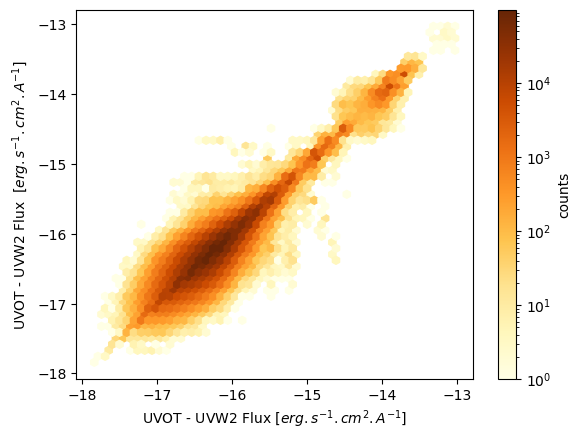

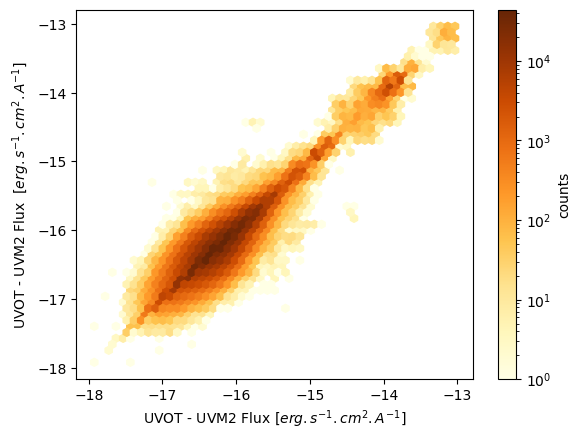

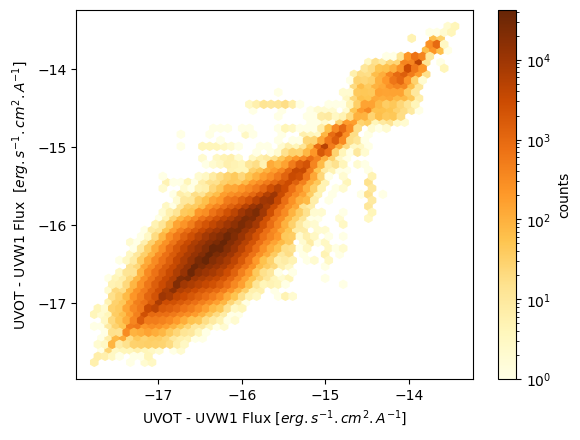

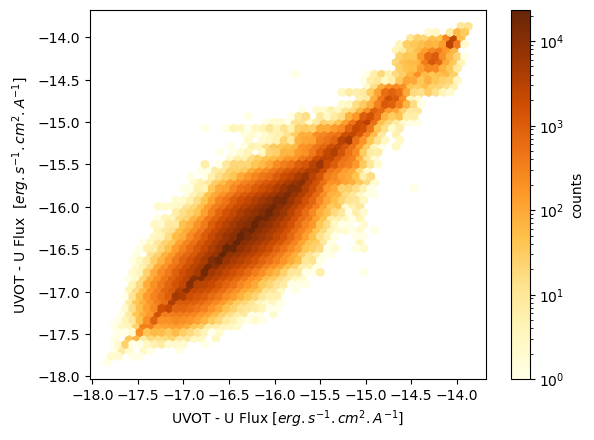

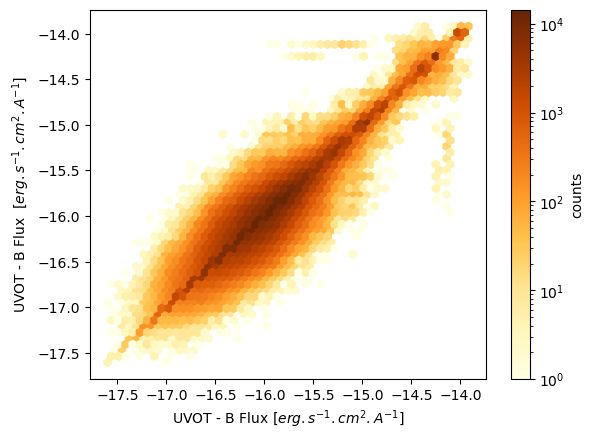

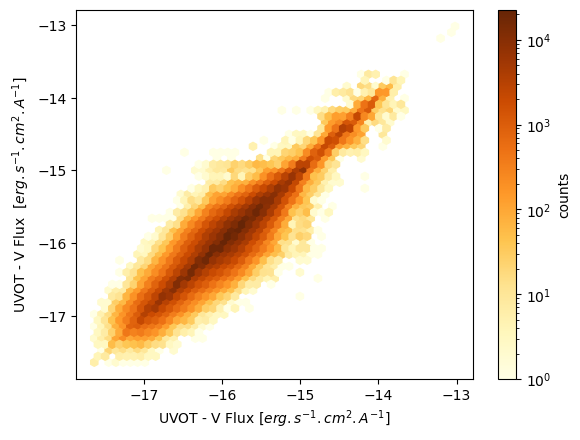

In [35]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    df_flux_uvot = df_flux_uvot.merge(df_flux_uvot, on='SRCNUM')

    # All combination of measurements for each sources  
    #first = 1
    #for name, group in df_flux_uvot.groupby('SRCNUM'):
    #    combined_tmp = np.array(np.meshgrid(group[flux_name],group[flux_name])).T.reshape(-1,2)
    #    if first==1:
    #        combined=combined_tmp
    #        first=0
    #    else:
    #        combined = np.concatenate((combined,combined_tmp),axis=0)      
            
    # Plot figure
    fig, ax =plt.subplots()
    hb =ax.hexbin(np.log10(df_flux_uvot[flux_name+'_x']),np.log10(df_flux_uvot[flux_name+'_y']),gridsize=50, bins='log', cmap='YlOrBr')
    cb = fig.colorbar(hb, ax=ax, label='counts')
    #data = np.vstack([np.log10(df_flux_uvot[flux_name+'_x']),np.log10(df_flux_uvot[flux_name+'_y'])])
    #kde = gaussian_kde(data)
    #grid_x, grid_y = np.mgrid[-18:-12.5:100j, -18:-11.5:100j]
    #grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    #z = kde(grid_coords).reshape(100, 100)**(1/3)
    #contour1 = ax.contourf(grid_x, grid_y, z, cmap='YlOrBr')
    #cbar = plt.colorbar(contour1, ax=ax)

    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("UVOT - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    fig.savefig(roots_tfm + '/Calibration/UVOT_vs_UVOT_ ' + flux + '_galaxies.png',dpi=1200)  

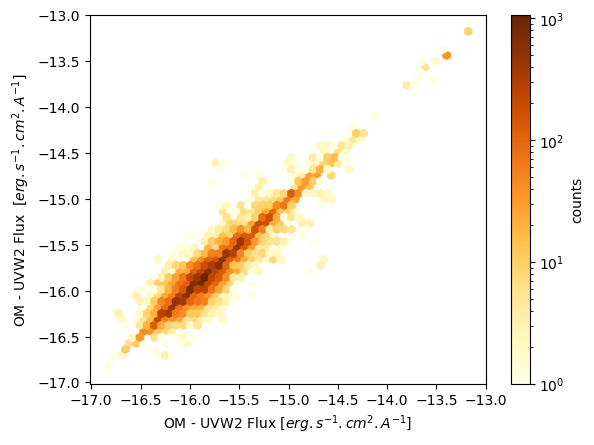

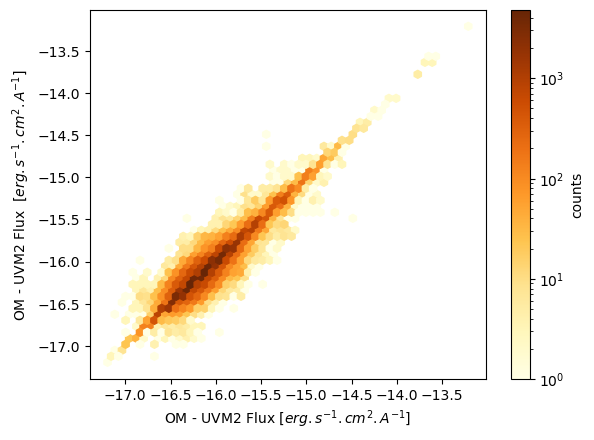

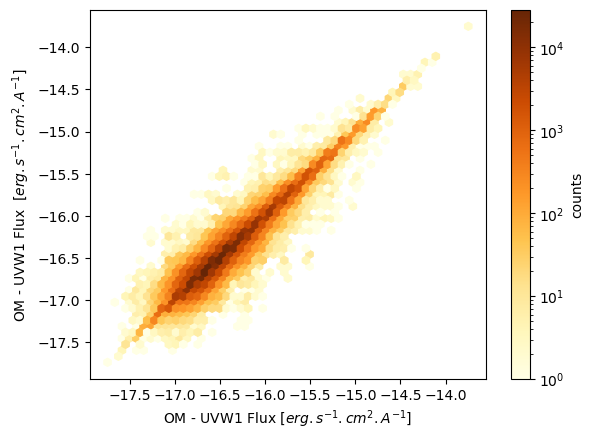

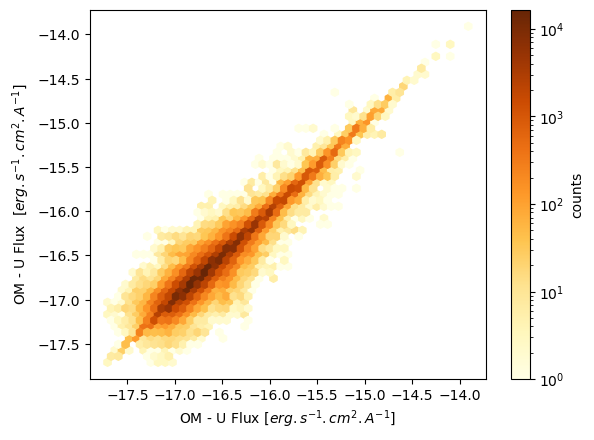

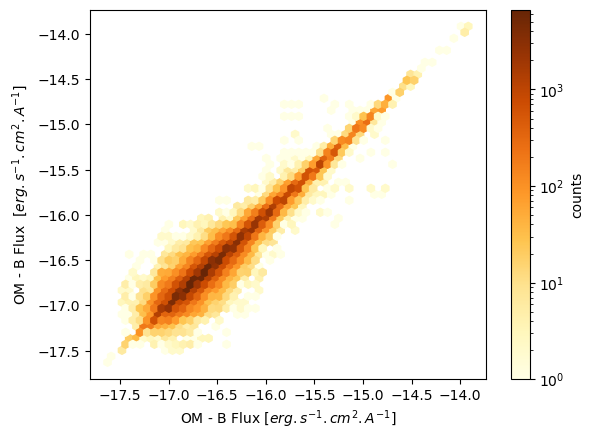

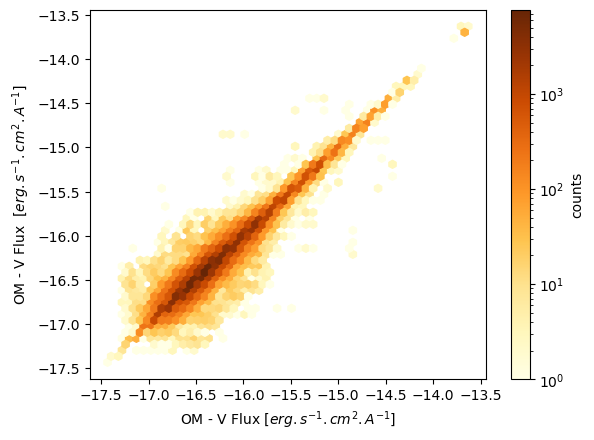

In [36]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]
    df_flux_om = df_flux_om.merge(df_flux_om, on='SRCNUM')

    # Plot figure
    fig, ax =plt.subplots()
    hb =ax.hexbin(np.log10(df_flux_om[flux_name+'_x']),np.log10(df_flux_om[flux_name+'_y']),gridsize=50, bins='log', cmap='YlOrBr')
    cb = fig.colorbar(hb, ax=ax, label='counts')

    ax.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("OM - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    fig.savefig(roots_tfm + '/Calibration/OM_vs_OM_ ' + flux + '_galaxies.png',dpi=1200) 

In [37]:
dat_OM_cor = dat_OM.copy()
dat_OM_cor = dat_OM_cor.astype({'UVW2_FLUX': np.float64, 'UVM2_FLUX': np.float64, 'UVW1_FLUX': np.float64, 'U_FLUX': np.float64,\
           'B_FLUX': np.float64, 'V_FLUX': np.float64})

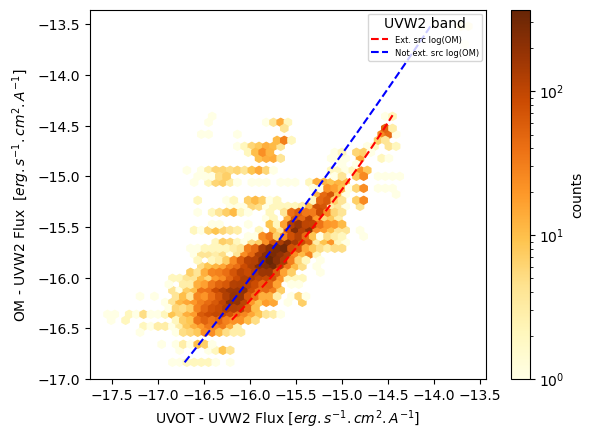

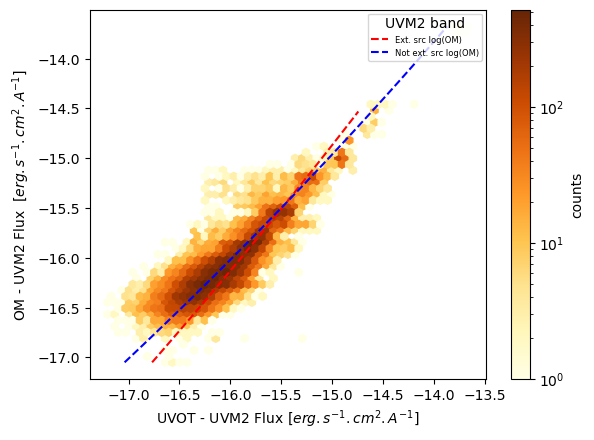

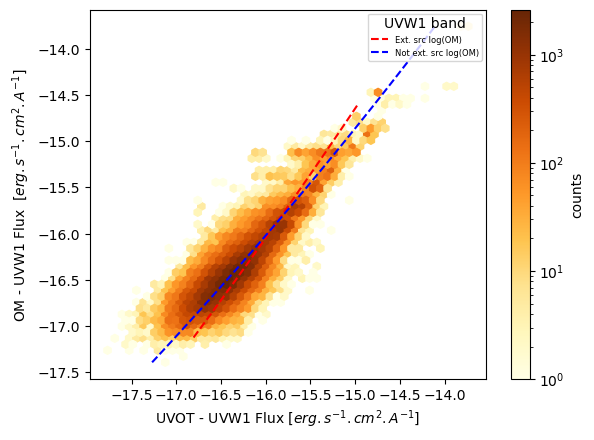

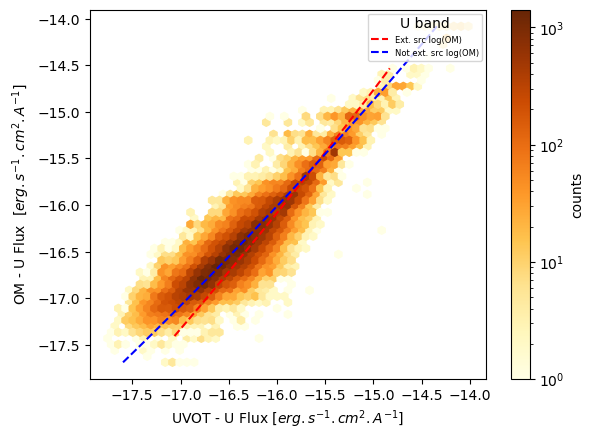

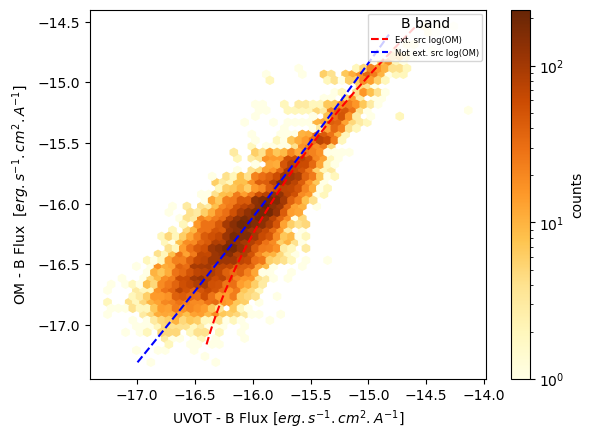

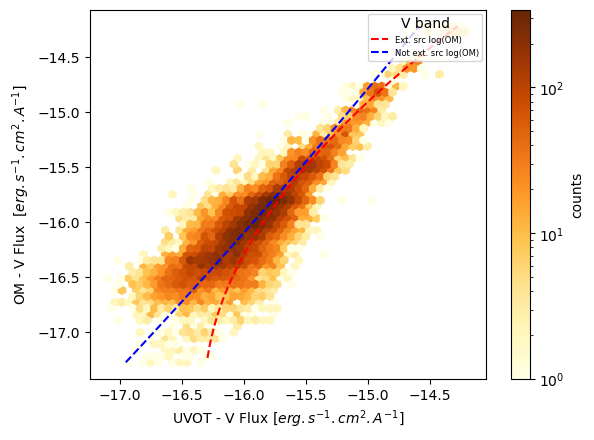

In [38]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    # Data frame OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    # Merge results
    df_match = df_match.rename(columns={'SRCNUM_UVOT':'SRCNUM_UVOT_1','SRCNUM_OM':'SRCNUM_OM_1'})
    df_merge = df_match.merge(df_flux_uvot, left_on='SRCNUM_UVOT_1', right_on='SRCNUM', 
                              suffixes=(None,'_UVOT')).merge(df_flux_om, left_on='SRCNUM_OM_1', 
                                                             right_on='SRCNUM',suffixes=('_UVOT','_OM'))

    # Plot figure
    fig, ax =plt.subplots()
    x=np.log10(df_merge[flux_name + '_UVOT'])
    y=np.log10(df_merge[flux_name + '_OM'])
    hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr')
    cb = fig.colorbar(hb, ax=ax, label='counts')

    #df_merge[flux_name + '_UVOT'] = df_merge[flux_name + '_UVOT'] + np.random.rand(df_merge[flux_name + '_UVOT'].shape[0])*1E-22
    #df_merge = df_merge.sort_values(by=flux_name + '_UVOT')
    
    ind_extended = (df_merge[flag_extended+ '_UVOT'] == "True") & (df_merge[flag_extended+ '_OM'] == "True")
    ind_not_extended = (df_merge[flag_extended+ '_UVOT'] == "False") & (df_merge[flag_extended+ '_OM'] == "False")
    
    #ax.scatter(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']), np.log10(df_merge.loc[ind1,flux_name + '_OM']), c='m',marker='x', \
    #           label='Ext. src')
    x=np.log10(df_merge.loc[ind_extended,flux_name + '_UVOT'])
    y=np.log10(df_merge.loc[ind_extended,flux_name + '_OM']) 
    #p = np.poly1d(np.polyfit(x,y, deg=3))
    #xp = np.linspace(x.min(), x.max(), 100)
    #ax.plot(xp,p(xp), color='r', linestyle='dashed', label= "Ext. src log(OM)")
    p = np.poly1d(np.polyfit(y,x, deg=3))
    yp = np.linspace(y.min(), y.max(), 100)
    ax.plot(p(yp), yp, color='r', linestyle='dashed', label= "Ext. src log(OM)")       
    #cs = CubicSpline(x,y)
    #xs = np.linspace(x.min(), x.max(), 100)
    #ax.plot(xs,cs(xs), color='r', linestyle='dashed', label= "Ext. src log(OM)")

    ind_extended_om = (dat_OM[flag_extended]=="True")
    #dat_OM_cor.loc[ind_extended_om, flux_name] = [10**fsolve(p-x,x)[0] for x in np.log10(dat_OM.loc[ind_extended_om, flux_name])]
    dat_OM_cor.loc[ind_extended_om, flux_name] = 10**p(np.log10(dat_OM.loc[ind_extended_om, flux_name]))

    x=np.log10(df_merge.loc[~ind_extended,flux_name + '_UVOT'])
    y=np.log10(df_merge.loc[~ind_extended,flux_name + '_OM']) 
    #p = np.poly1d(np.polyfit(x,y, deg=3))
    #xp = np.linspace(x.min(), x.max(), 100)
    #ax.plot(xs,p(xp), color='b', linestyle='dashed', label= "Not ext. src log(OM)")
    p = np.poly1d(np.polyfit(y,x, deg=3))
    yp = np.linspace(y.min(), y.max(), 100)
    ax.plot(p(yp), yp, color='b', linestyle='dashed', label= "Not ext. src log(OM)")
    #cs = CubicSpline(x,y)
    #xs = np.linspace(x.min(), x.max(), 100)
    #ax.plot(xs,cs(xs), color='b', linestyle='dashed', label= "Not ext. src log(OM)")
    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("OM - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.legend(loc='upper right',prop={'size': 6},title= flux + " band")
    fig.savefig(roots_tfm + '/Calibration/UVOT_vs_OM_ ' + flux + '_galaxies2.png',dpi=1200)  

    #dat_OM_cor.loc[~ind_extended_om, flux_name] = 10**cs.solve(np.log10(dat_OM.loc[~ind_extended_om, flux_name]))
    #dat_OM_cor.loc[~ind_extended_om, flux_name] = [10**fsolve(p-x,x)[0] for x in np.log10(dat_OM.loc[~ind_extended_om, flux_name])]
    dat_OM_cor.loc[~ind_extended_om, flux_name] = 10**p(np.log10(dat_OM.loc[~ind_extended_om, flux_name]))

In [39]:
df_match.shape

(595146, 2)

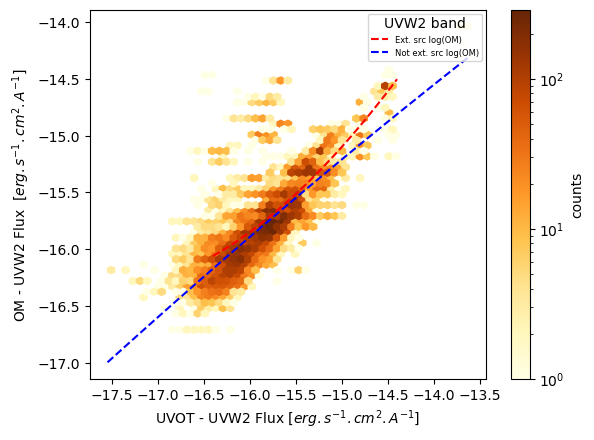

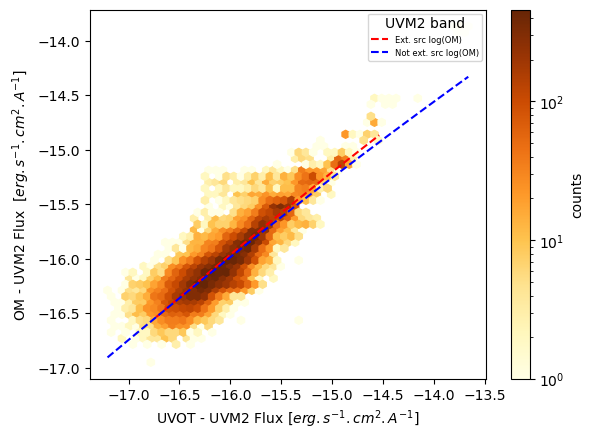

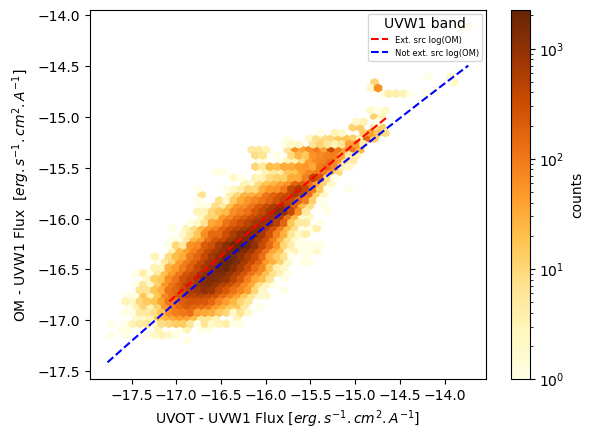

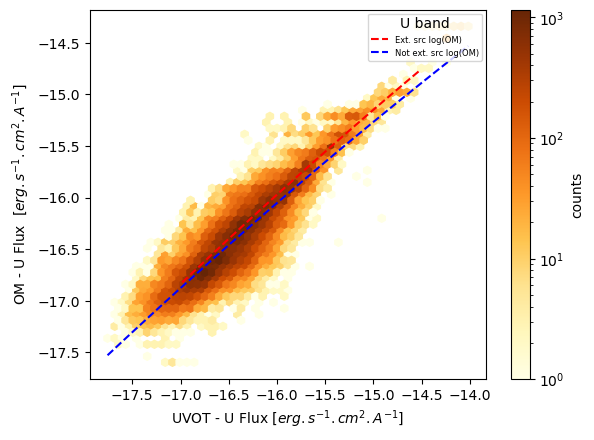

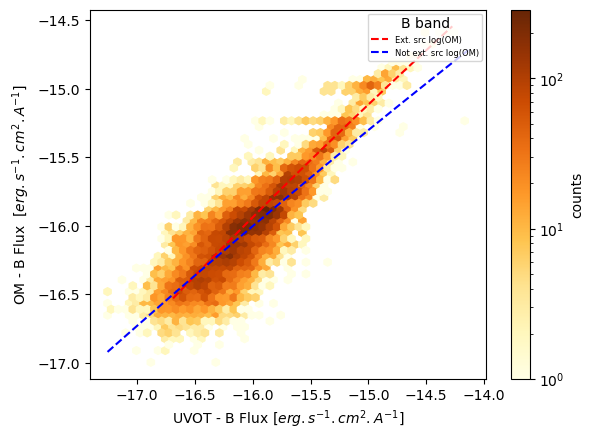

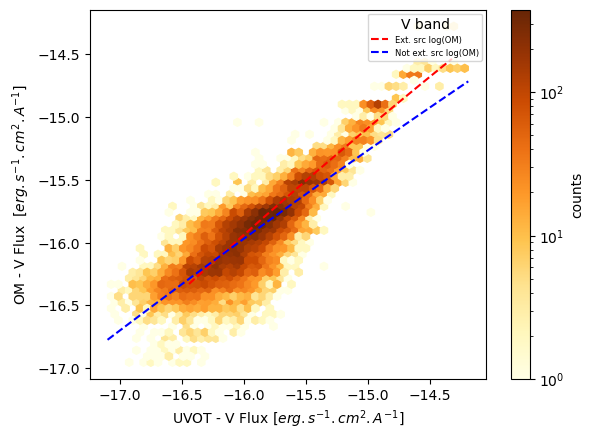

In [41]:
for flux in ['UVW2','UVM2','UVW1','U','B','V']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    # Data frame OM for this band
    df_flux_om = dat_OM_cor[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    # Merge results
    df_match = df_match.rename(columns={'SRCNUM_UVOT':'SRCNUM_UVOT_1','SRCNUM_OM':'SRCNUM_OM_1'})
    df_merge = df_match.merge(df_flux_uvot, left_on='SRCNUM_UVOT_1', right_on='SRCNUM', 
                              suffixes=(None,'_UVOT')).merge(df_flux_om, left_on='SRCNUM_OM_1', 
                                                             right_on='SRCNUM',suffixes=('_UVOT','_OM'))

    # Plot figure
    fig, ax =plt.subplots()
    x=np.log10(df_merge[flux_name + '_UVOT'])
    y=np.log10(df_merge[flux_name + '_OM'])
    hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr')
    cb = fig.colorbar(hb, ax=ax, label='counts')
    
    ind_extended = (df_merge[flag_extended+ '_UVOT'] == "True") & (df_merge[flag_extended+ '_OM'] == "True")
    ind_not_extended = (df_merge[flag_extended+ '_UVOT'] == "False") & (df_merge[flag_extended+ '_OM'] == "False")
    
    #ax.scatter(np.log10(df_merge.loc[ind1,flux_name + '_UVOT']), np.log10(df_merge.loc[ind1,flux_name + '_OM']), c='m',marker='x', \
    #           label='Ext. src')
    x=np.log10(df_merge.loc[ind_extended,flux_name + '_UVOT'])
    y=np.log10(df_merge.loc[ind_extended,flux_name + '_OM'])   
    p = np.poly1d(np.polyfit(x,y, deg=3))
    xp = np.linspace(x.min(), x.max(), 100)
    ax.plot(xp,p(xp), color='r', linestyle='dashed', label= "Ext. src log(OM)")

    x=np.log10(df_merge.loc[~ind_extended,flux_name + '_UVOT'])
    y=np.log10(df_merge.loc[~ind_extended,flux_name + '_OM'])   
    p = np.poly1d(np.polyfit(x,y, deg=3))
    xp = np.linspace(x.min(), x.max(), 100)
    ax.plot(xp,p(xp), color='b', linestyle='dashed', label= "Not ext. src log(OM)")
    ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.set_ylabel("OM - " + flux + ' Flux  [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
    ax.legend(loc='upper right',prop={'size': 6},title= flux + " band")

In [42]:
df_match = Table.read( roots_tfm + '/Swift-UVOT/Match_OM/match_uvot_om').to_pandas()
for flux in ['UVW2']: 
    
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index() 
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    # Data frame OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    # Merge results
    df_match = df_match.rename(columns={'SRCNUM_UVOT':'SRCNUM_UVOT_1','SRCNUM_OM':'SRCNUM_OM_1'})
    df_merge = df_match.merge(df_flux_uvot, left_on='SRCNUM_UVOT_1', right_on='SRCNUM', 
                              suffixes=(None,'_UVOT')).merge(df_flux_om, left_on='SRCNUM_OM_1', 
                                                             right_on='SRCNUM',suffixes=('_UVOT','_OM'))

    df_results=pd.DataFrame()
    df_results['SRCNUM_UVOT'] = df_merge.loc[(np.log10(df_merge[flux_name + '_UVOT']) < -15.5) & (np.log10(df_merge[flux_name + '_UVOT']) > -16) &
    (np.log10(df_merge[flux_name + '_OM']) < -14.5) & (np.log10(df_merge[flux_name + '_OM']) > -15.0),'SRCNUM_UVOT'].unique()
    df_results = df_results.merge(df_match, left_on='SRCNUM_UVOT',right_on='SRCNUM_UVOT_1')

In [43]:
df_results.head(6)

,SRCNUM_UVOT,SRCNUM_OM_1,RA_OM,DEC_OM,POSERR_OM,COUNT_OM,SRCNUM_UVOT_1,RA_UVOT,DEC_UVOT,POSERR_UVOT,COUNT_UVOT,Separation,angDist
0,1430339,2332235,107.151007,-49.638083,0.529961,14,1430339,107.151140,-49.638074,0.437230,44,0.107509,0.311947
1,1431083,2332507,107.169295,-49.462008,0.595176,15,1431083,107.169187,-49.462094,0.466503,40,0.124808,0.397520
2,1435016,2334519,107.242431,-49.526071,0.529541,15,1435016,107.242369,-49.526094,0.440629,45,0.057417,0.167114
3,1436052,2335099,107.259729,-49.563357,0.563383,15,1436052,107.259724,-49.563378,0.453429,45,0.025132,0.076664
4,1437081,2335625,107.275608,-49.523369,0.559267,14,1437081,107.275529,-49.523415,0.444133,45,0.082329,0.247825
5,1437436,2335818,107.281124,-49.559296,0.613585,9,1437436,107.280867,-49.559321,0.549082,5,0.173990,0.606878


In [ ]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
dat_UVOT.to_sql("Entries_UVOT", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")
dat_OM_cor.to_sql("Entries_OM", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")

In [ ]:
dat_OM_cor.to_csv(roots_tfm + '/XMM-Newton/Entries_OM_galaxies.csv',index=True)
dat_UVOT.to_csv(roots_tfm + '/Swift-UVOT/Entries_UVOT_galaxies.csv',index=True)

In [ ]:
#dat_UVOT.to_parquet(roots_tfm + '/'+project+'/'+'Entries_UVOT_parquet')